# 실습 2. 오즈비와 로지스틱 회귀 계수 해석

## 데이터
- 직접 만든 구매 데이터 사용
- `gender`: 성별 그룹
- `buy`: 구매 여부. `1`은 구매, `0`은 비구매

## 실습 목표
- 확률, 오즈, 오즈비를 직접 계산
- 2x2 교차표에서 오즈비 계산
- 로지스틱 회귀의 `coef_`를 `np.exp()`로 오즈비로 변환
- 간단한 그래프로 그룹별 구매율 비교

## 주의
- 오즈비는 확률의 배수가 아니라 오즈의 배수임.
- 로지스틱 회귀 계수는 확률 변화량이 아니라 로그 오즈 변화량임.


In [1]:
from xml.etree.ElementPath import prepare_descendant

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from altair.vegalite.v6 import display

from sklearn.linear_model import LogisticRegression

# 남성: 구매 30명, 비구매 70명
# 여성: 구매 50명, 비구매 50명
purchase_df = pd.DataFrame({
    'gender': ['male'] * 100 + ['female'] * 100,
    'buy': [1] * 30 + [0] * 70 + [1] * 50 + [0] * 50,
})

print(purchase_df.shape)
display(purchase_df.head())
print(purchase_df.groupby('gender')['buy'].value_counts().sort_index())

(200, 2)


,gender,buy
0,male,1
1,male,1
2,male,1
3,male,1
4,male,1


gender  buy
female  0      50
        1      50
male    0      70
        1      30
Name: count, dtype: int64


## 문제 1. 그룹별 구매 확률과 오즈 계산

성별 그룹별로 구매 확률과 구매 오즈를 계산하세요.

### 요구사항
- 남성 구매 확률 계산
- 여성 구매 확률 계산
- 남성 구매 오즈 계산
- 여성 구매 오즈 계산

### 힌트
- 확률: `구매 수 / 전체 수`
- 오즈: `구매 수 / 비구매 수`

### 실행 결과

```text
        sum  count  not_buy  buy_probability  buy_odds
gender                                                
female   50    100       50              0.5  1.000000
male     30    100       70              0.3  0.428571

남성 구매 확률: 0.3
여성 구매 확률: 0.5
남성 구매 오즈: 0.42857142857142855
여성 구매 오즈: 1.0
```


In [8]:
summary_df = purchase_df.groupby('gender')['buy'].agg(['sum', 'count'])
summary_df['not_buy'] = summary_df['count'] - summary_df['sum']
summary_df['buy_probability'] = summary_df['sum'] / summary_df['count']
summary_df['buy_odds'] = summary_df['sum'] / summary_df['not_buy']

display(summary_df)

print("남성 구매 확률:", summary_df.loc['male','buy_probability'])
print("여성 구매 확률:", summary_df.loc['female','buy_probability'])
print("남성 구매 오즈:", summary_df.loc['male','buy_odds'])
print("여성 구매 오즈:", summary_df.loc['female','buy_odds'])


,sum,count,not_buy,buy_probability,buy_odds
gender,,,,,
female,50,100,50,0.5,1.000000
male,30,100,70,0.3,0.428571


남성 구매 확률: 0.3
여성 구매 확률: 0.5
남성 구매 오즈: 0.42857142857142855
여성 구매 오즈: 1.0


## 문제 2. 2x2 교차표로 오즈비 계산

남성과 여성의 구매 오즈를 비교해 오즈비를 계산하세요.

### 요구사항
- 남성/여성별 구매/비구매 수로 2x2 표 생성
- 남성 기준 오즈비 계산
- 여성 기준 오즈비 계산

### 힌트
- 남성 기준 오즈비: `남성 오즈 / 여성 오즈`
- 여성 기준 오즈비: `여성 오즈 / 남성 오즈`

### 실행 결과

```text
        buy  not_buy
male     30       70
female   50       50

남성 기준 오즈비(남성/여성): 0.429
여성 기준 오즈비(여성/남성): 2.333
```


In [15]:
male_buy = summary_df.loc['male', 'sum']
male_not_buy = summary_df.loc['male', 'not_buy']
female_buy = summary_df.loc['female', 'sum']
female_not_buy = summary_df.loc['female', 'not_buy']

odds_table = pd.DataFrame(
    {
        'buy': [male_buy, female_buy],
        'not_buy': [male_not_buy, female_not_buy],
    },
    index=['male', 'female']
)

display(odds_table)

# odds
male_odds = male_buy / male_not_buy
female_odds = female_buy / female_not_buy

# 남성 기준 오즈비
male_or = male_odds / female_odds
# 여성 기준 오즈비
female_or = female_odds / male_odds
print(male_or, female_or)
print(f'남성 기준 오즈비(남성/여성): {male_or:.3f}')
print(f'여성 기준 오즈비(여성/남성): {female_or:.3f}')

,buy,not_buy
male,30,70
female,50,50


0.42857142857142855 2.3333333333333335
남성 기준 오즈비(남성/여성): 0.429
여성 기준 오즈비(여성/남성): 2.333


## 문제 3. 로지스틱 회귀 계수로 오즈비 계산

성별을 숫자로 바꾼 뒤 로지스틱 회귀 모델을 학습하고 계수를 오즈비로 변환하세요.

### 요구사항
- `male`은 0, `female`은 1로 변환
- `LogisticRegression` 모델 학습
- `coef_`, `intercept_` 출력
- `np.exp(coef_)`로 오즈비 계산

### 힌트
- `gender_code`가 0에서 1로 바뀌는 효과를 학습함.
- 따라서 오즈비는 여성의 구매 오즈가 남성에 비해 몇 배인지로 해석함.

### 실행 결과

```text
회귀계수: 0.779
절편: -0.810
오즈비(여성/남성): 2.180
```


In [10]:
purchase_df['gender_code'] = purchase_df['gender'].map({'male': 0, 'female': 1})

X = purchase_df[['gender_code']]
y = purchase_df['buy']

log_reg = LogisticRegression()
log_reg.fit(X, y)

# 회귀계수
coef = log_reg.coef_[0][0]

# 절편
intercept = log_reg.intercept_[0]

# 오즈비 == exp(회귀계수)
odds_ratio = np.exp(coef)

print(f'회귀계수: {coef:.3f}')
print(f'절편: {intercept:.3f}')
print(f'오즈비(여성/남성): {odds_ratio:.3f}')

회귀계수: 0.779
절편: -0.810
오즈비(여성/남성): 2.180


## 문제 4. 예측 확률과 오즈비 해석

로지스틱 회귀 모델로 남성과 여성의 구매 확률을 예측하고, 오즈비 해석 문장을 작성하세요.

### 요구사항
- `gender_code=0`, `gender_code=1`에 대한 구매 확률 예측
- 예측 확률을 표로 정리
- 오즈비 해석 문장 출력

### 힌트
- `predict_proba()`의 두 번째 컬럼은 클래스 `1`, 즉 구매 확률임.

### 실행 결과

```text
        gender_code  pred_buy_probability
male              0              0.307784
female            1              0.492207

해석: 여성의 구매 오즈는 남성의 구매 오즈보다 약 2.33배 높음.
주의: 구매 확률이 약 2.33배 높다는 뜻이 아니라, 구매 오즈가 약 2.33배 높다는 뜻임.
```


In [14]:
new_customers = pd.DataFrame({'gender_code': [0, 1]}, index=['male', 'female'])
predicted_proba = log_reg.predict_proba(new_customers)[:, 1]

df = pd.DataFrame({
    'gender_code' : new_customers['gender_code'],
    'pred_buy_probability' : predicted_proba
})

display(df)

,gender_code,pred_buy_probability
male,0,0.307794
female,1,0.492207


## 문제 5. 그룹별 구매율 그래프 그리기

성별 그룹별 구매율을 막대그래프로 그리세요.

### 요구사항
- x축은 성별
- y축은 구매율
- y축 범위는 0~1
- 막대 위에 구매율 숫자 표시

### 힌트
- 구매율은 `buy`의 평균으로 계산할 수 있음.

### 실행 결과

```text
성별 구매율 막대그래프가 출력됨.
male 구매율: 0.30
female 구매율: 0.50
```


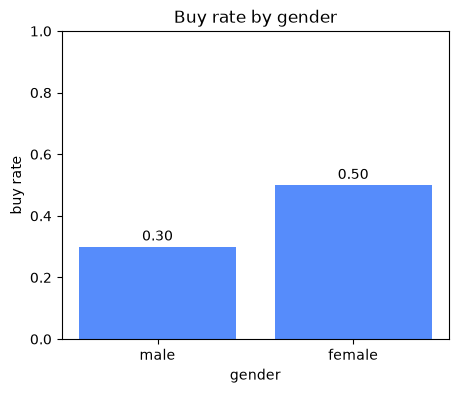

In [18]:
buy_rate = purchase_df.groupby('gender')['buy'].mean().reindex(['male', 'female'])

plt.figure(figsize=(5, 4))
bars = plt.bar(buy_rate.index, buy_rate.values)
plt.ylim(0, 1)
plt.xlabel('gender')
plt.ylabel('buy rate')
plt.title('Buy rate by gender')

for bar, value in zip(bars, buy_rate.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.02,
        f'{value:.2f}',
        ha='center'
    )

plt.show()